# Quality Assessment
Now it's your turn. Follow the steps on the platform and use what you've learnt to see how reliable the data is.

Load our cleaned DataFrames

In [167]:
import pandas as pd

In [129]:
orders_cl = pd.read_csv("orders_cl.csv")
orderlines_cl = pd.read_csv("orderlines_cl.csv")
products_cl = pd.read_csv("products_cl.csv")
brands_cl = pd.read_csv("brands_cl.csv")

In [130]:
orders_qu = orders_cl.copy()
orderlines_qu = orderlines_cl.copy()
products_qu = products_cl.copy()

## 1.&nbsp; Define Pandas display format

In [131]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

## 2.&nbsp; Exclude unwanted orders

In [113]:
orders_qu.shape

(226904, 4)

In [112]:
orders_qu["state"].value_counts()

state
Shopping Basket    117809
Completed           46605
Place Order         40883
Pending             14374
Cancelled            7233
Name: count, dtype: int64

In [132]:
orders_qu = orders_qu.loc[(orders_qu["state"] == "Completed")]
# 20% of the data is retained

In [133]:
orders_qu["state"].value_counts()

state
Completed    46605
Name: count, dtype: int64

In [114]:
46605/226904 * 100

20.53952332263865

In [134]:
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(orders_qu["order_id"]), :]

In [135]:
orderlines_cl.shape

(216250, 7)

In [136]:
orderlines_qu.shape[0]


56714

In [122]:
56714/216250 * 100
# 26.2% of the data retained

26.226127167630057

In [137]:
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(orderlines_qu["id_order"])]
# order with no item line in orderline df filtered - to check ripple effect

In [124]:
orders_qu.shape[0]

46605

## 3.&nbsp; Exclude orders with unknown products


In [139]:
orderlines_products = orderlines_qu.merge(products_qu, how="left", on = "sku")[["id_order","sku","name" ]]

In [140]:
orderlines_products.name.isna().value_counts()

name
False    55320
True      1394
Name: count, dtype: int64

In [141]:
orders_to_delete = orderlines_products.loc[orderlines_products.name.isna(), "id_order"].unique()
orders_to_delete

array([299638, 299706, 299712, ..., 526106, 526122, 526363], shape=(1363,))

In [142]:
orders_qu = orders_qu.loc[~orders_qu.order_id.isin(orders_to_delete),:]
orderlines_qu = orderlines_qu.loc[~orderlines_qu.id_order.isin(orders_to_delete),:]

In [143]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(41701, 41701)

## 4.&nbsp; Explore the revenue from different tables

#### Step 1:
Create the `unit_price_total` as `orderlines.unit_price` * `orderlines.product_quantity`

In [144]:
orders_qu_copy = orders_qu.copy()

In [145]:
orderlines_qu_copy = orderlines_qu.copy()

In [146]:
orderlines_qu_copy["unit_price_total"] = orderlines_qu_copy["product_quantity"] * orderlines_qu_copy["unit_price"]
orderlines_qu_copy

,id,id_order,product_id,product_quantity,sku,unit_price,date,unit_price_total
6,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,47.49
7,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,18.99
8,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,72.19
15,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,60.90
21,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,142.49
...,...,...,...,...,...,...,...,...
215889,1649474,525664,0,1,TUC0207,16.52,2018-03-14 11:45:05,16.52
215906,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,19.98
215911,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,19.98
215932,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,29.97


#### Step 2:
Group by `id_order`, summarising by the sum of `unit_price_total`

In [147]:
orderlines_order_ids = orderlines_qu_copy.groupby("id_order", as_index=False)["unit_price_total"].sum()

In [148]:
orderlines_order_ids

,id_order,unit_price_total
0,241423,129.16
1,242832,10.77
2,243330,77.99
3,245275,149.00
4,245595,105.98
...,...,...
41696,527042,13.99
41697,527070,19.98
41698,527074,19.98
41699,527096,29.97


### What is the average difference between `total_paid` and `unit_price_total`?

In [149]:
diff_df = orders_qu_copy.merge(orderlines_order_ids, left_on="order_id", right_on="id_order")
diff_df

,order_id,created_date,total_paid,state,id_order,unit_price_total
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98
...,...,...,...,...,...,...
41696,527042,2018-03-14 11:47:50,18.98,Completed,527042,13.99
41697,527070,2018-03-14 11:50:48,24.97,Completed,527070,19.98
41698,527074,2018-03-14 11:51:42,24.97,Completed,527074,19.98
41699,527096,2018-03-14 11:58:40,34.96,Completed,527096,29.97


In [150]:
diff_df.shape[0]

41701

In [151]:
diff_df["difference"] = diff_df["total_paid"] - diff_df["unit_price_total"]

In [152]:
diff_df.difference.mean().round(2)

np.float64(4.47)

### What is the distribution of these differences?

<Axes: >

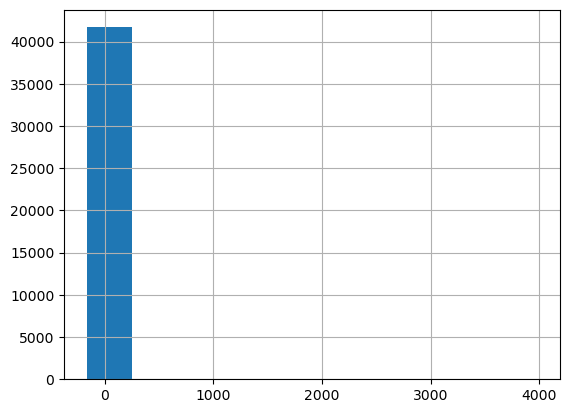

In [153]:
diff_df.difference.hist()

### Can all the differences be explained by shipping costs? If not, what are other plausible explanations?

<Axes: >

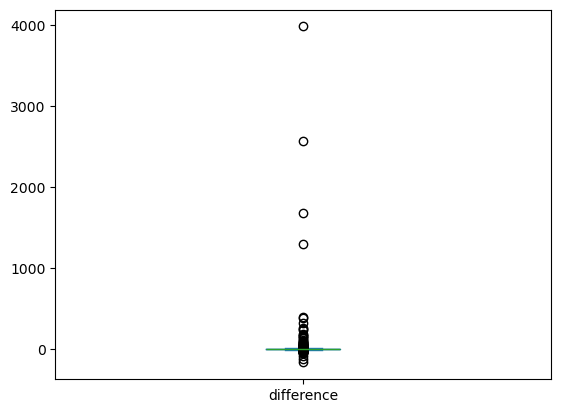

In [154]:
diff_df.difference.plot.box()

In [157]:
Q1 = diff_df["difference"].quantile(0.25)
Q3 = diff_df["difference"].quantile(0.75)
IQR = Q3 - Q1
IQR

np.float64(6.989999999999981)

In [156]:
upper_bound = Q3 + 1.5 * IQR
upper_bound
# 12.5

np.float64(17.47499999999995)

In [159]:
lower_bound = Q1 - 1.5 * IQR
lower_bound

np.float64(-10.484999999999971)

In [160]:
# filter the DataFrame to include only "non-outliers"
diff_no_outliers_df = diff_df.loc[
    (diff_df["difference"] >= (Q1 - 1.5*IQR))
    &
    (diff_df["difference"] <= (Q3 + 1.5*IQR))
    ,
    :]

<Axes: >

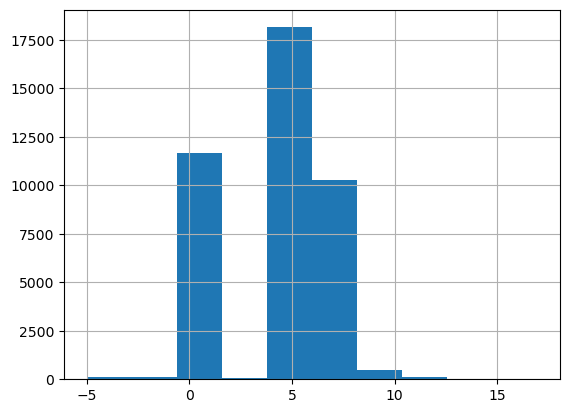

In [161]:
diff_no_outliers_df.difference.hist()

<Axes: >

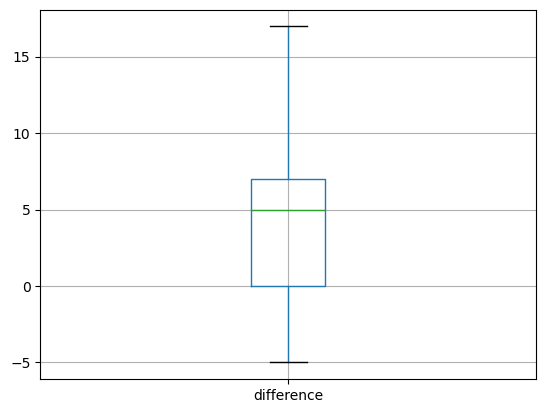

In [162]:
diff_no_outliers_df.boxplot("difference")

### If there are differences that you can’t explain: what should you do with these orders?

In [164]:
normal_diff_list = diff_no_outliers_df["order_id"]

In [165]:
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(normal_diff_list), :]
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(normal_diff_list), :]

In [166]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(40985, 40985)

## 5.&nbsp; Become confident about your dataset

Let's hear your thoughts about what you discovered.

In [ ]:
# your thoughts & code here
# with reasoned cutoff 200, found 157 unexplained orders - Flagging instead of drop


# Products

In [ ]:
products_qu

In [169]:
orderlines_products_price = orderlines_qu.merge(products_qu, on="sku", how="inner")[["sku", "unit_price", "price"]]

In [170]:
orderlines_products_price

,sku,unit_price,price
0,OWC0100,47.49,60.99
1,IOT0014,18.99,22.95
2,APP0700,72.19,89.00
3,CRU0039-A,60.90,76.99
4,PEB0015,142.49,299.99
...,...,...,...
53226,APP0698,9.99,25.00
53227,APP0698,9.99,25.00
53228,APP0698,9.99,25.00
53229,APP0698,9.99,25.00


In [171]:
orderlines_products_price["up_difference"] = orderlines_products_price["price"] - orderlines_products_price["unit_price"]

In [173]:
orderlines_products_price["up_difference"].median()

np.float64(-15.0)

In [179]:
Q1 = orderlines_products_price["up_difference"].quantile(0.25)
Q3 = orderlines_products_price["up_difference"].quantile(0.75)
IQR = Q3 - Q1
print(IQR)
print(Q3)
print(Q1)

25.749999999999996
-5.2500000000000036
-31.0


In [181]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)

-69.625
33.374999999999986


In [ ]:
# (-69.6 to 33.4) — meaning most of your data isn't flagged as an "outlier" at all. 
# IQR filtering would trim the extreme tails, but it won't help to identify the negative pattern.

## Is unit_price for the same SKU constant over time

In [ ]:
sample_skus = orderlines_qu["sku"].sample(5, random_state=1)
# random_state=1, you get the same 5 SKUs every time 

check_df = (
    orderlines_qu.loc[orderlines_qu["sku"].isin(sample_skus), ["sku", "unit_price", "date"]]
    .merge(products_qu[["sku", "price"]], on="sku", how="left")
)

check_df.sort_values(["sku", "date"])

<Axes: xlabel='date'>

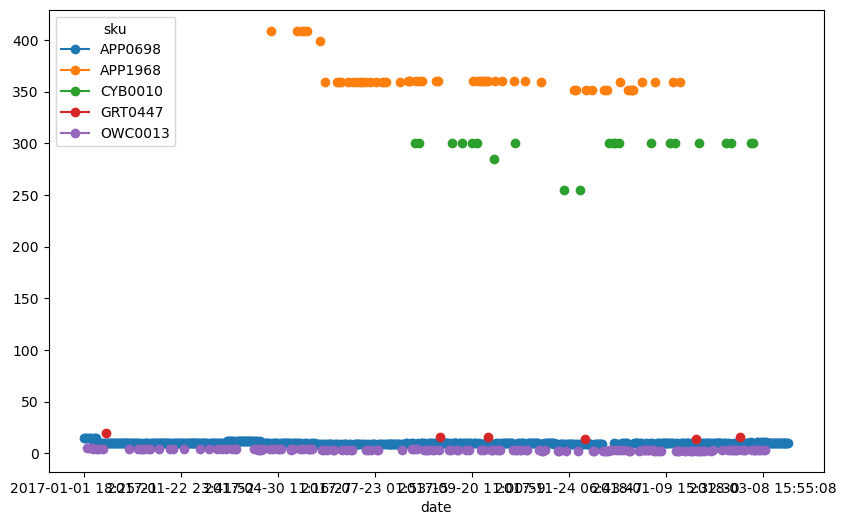

In [184]:
pivot_df = check_df.pivot(index="date", columns="sku", values="unit_price")
pivot_df.plot.line(figsize=(10,6), marker="o")

In [188]:
orders_qu.to_csv("orders_qu.csv", index=False)
orderlines_qu.to_csv("orderlines_qu.csv", index=False)

In [203]:
orderprice_recent = orderlines_qu.loc[orderlines_qu.groupby("sku")["date"].idxmax(),["sku","unit_price"]]

In [206]:
disc_compare = products_cl.merge(orderprice_recent, on="sku", how="inner")
disc_compare

,sku,name,desc,price,promo_price,in_stock,type,unit_price
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,499.899,1,8696,49.99
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,589.996,0,13855401,59.00
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,569.898,0,1387,56.99
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,229.997,0,1230,23.99
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,31.99,1,1364,34.99
...,...,...,...,...,...,...,...,...
5093,APP1466,Apple Magic Mouse 2 (OEM),Apple Bluetooth wireless mouse original box,89.00,799.895,1,1387,69.99
5094,MMW0014,"My MW Case MacBook Pro 13 ""(Late 2016) Coral",Avoid shock and damage to your MacBook Pro 13-...,29.99,20.99,1,13835403,19.54
5095,MMW0013,"My MW Case MacBook Pro 13 ""(Late 2016) White S...",Avoid shock and damage to your MacBook Pro 13-...,29.99,20.99,1,13835403,22.99
5096,MMW0016,"My MW Case MacBook Pro 13 ""(Late 2016) Black",Avoid shock and damage to your MacBook Pro 13-...,29.99,20.99,1,13835403,22.99


In [208]:
disc_compare["diff"]= disc_compare["price"]-disc_compare["unit_price"]
disc_compare

,sku,name,desc,price,promo_price,in_stock,type,unit_price,diff
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,499.899,1,8696,49.99,10.00
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,589.996,0,13855401,59.00,0.00
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,569.898,0,1387,56.99,2.01
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,229.997,0,1230,23.99,1.01
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,31.99,1,1364,34.99,0.00
...,...,...,...,...,...,...,...,...,...
5093,APP1466,Apple Magic Mouse 2 (OEM),Apple Bluetooth wireless mouse original box,89.00,799.895,1,1387,69.99,19.01
5094,MMW0014,"My MW Case MacBook Pro 13 ""(Late 2016) Coral",Avoid shock and damage to your MacBook Pro 13-...,29.99,20.99,1,13835403,19.54,10.45
5095,MMW0013,"My MW Case MacBook Pro 13 ""(Late 2016) White S...",Avoid shock and damage to your MacBook Pro 13-...,29.99,20.99,1,13835403,22.99,7.00
5096,MMW0016,"My MW Case MacBook Pro 13 ""(Late 2016) Black",Avoid shock and damage to your MacBook Pro 13-...,29.99,20.99,1,13835403,22.99,7.00


# products_cl Finding
Quality assessment note - products_cl.price
products_cl.price appears to be a single, current/recent price snapshot, not a historical record.
Comparing it against ALL historical unit_price data (orderlines_qu) gave a misleading negative
average difference (-26.12), since older unit_price values were often higher than today's list price.
Comparing against only each SKU's MOST RECENT sale gave a positive average (+37.27, median +14),
consistent with expected discounts.
No row-level fix applied - this is a documented limitation, not a data error.
Caution: products_cl.price should not be used to assess historical pricing/discounts directly;
only reliable for comparison against recent/current transactions.